In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt

## Analysis of Columns
**Target Column** - Price_per_SqFt  
**Numerical Columns**  
*(int64)*
1. ID              : Should be removed
2. BHK             : Data ranges from 1 - 5 all having median price similar
3. Size_in_SqFt    : Debatable
4. Year_Built      : Can be removed as we already have age of property
5. Floor_No        : issue
6. Total_Floors    : issue
7. Age_of_Property : Range from 2 - 35 whole numbers
8. Nearby_Schools  : Data range from 1 - 10
9. Nearby_Hospitals: Data range from 1 - 10

*(float64)*
1. Price_in_Lakhs  : Target Column
2. Price_in_SqFt   : Can be removed as we already have price_in_Lakhs

# Categorical Columns Analysis

**Categorical Columns**
1. State                              : 20 different states (Target encoding)
2. City                               : 42 different cities (Target encoding)
3. Locality                           : high cardinality (500), one hot, ordinal encoding not much effective (frequency encoding) 
4. Property_Type                      : (3 types) (one-hot encoding)
5. Furnished_Status                   : (3 types) hiarchical (ordinal encoding)
6. Public_Transport_Accessibility     : (3 types) hiarchical (ordinal encoding)
7.  Parking_Space                     : Yes/No (binary)
8.  Security                          : Yes/No (binary)
9.  Amenities                         : can be changed to numerical [5 amenities]
10.  Facing                           : 4 directions (ordinal encoding)
11.  Owner_Type                       : Broker builder owner can be dropped
12.  Availability_Status              : under construction ,ready (ordinal encoding)

***This data was syntetically created as hence it doesn't have any correlation to price.***  
***Cancelled the dataset***

# Restart : New dataset-"melb_data.csv"

In [17]:
# Displaying the dataset
df = pd.read_csv("../dataset/melb_data.csv",thousands=",")
df.tail()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0
13579,Yarraville,6 Agnes St,4,h,1285000.0,SP,Village,26/08/2017,6.3,3013.0,...,1.0,1.0,362.0,112.0,1920.0,NaN,-37.81188,144.88449,Western Metropolitan,6543.0


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

In [19]:
## Checking for null values

df.isna().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [20]:
numerical_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(include=["object", "string"]).columns

numerical_cols, categorical_cols

(Index(['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
        'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude',
        'Propertycount'],
       dtype='str'),
 Index(['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea',
        'Regionname'],
       dtype='str'))

In [21]:
# Checking for null values for each category:
df[numerical_cols].isnull().sum()

Rooms               0
Price               0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
Lattitude           0
Longtitude          0
Propertycount       0
dtype: int64

In [22]:
df[categorical_cols].isnull().sum()

Suburb            0
Address           0
Type              0
Method            0
SellerG           0
Date              0
CouncilArea    1369
Regionname        0
dtype: int64

# Numerical Columns Analysis

## Mean Median and Mode for Numerical columns

In [23]:
for col in numerical_cols:
    print(f"\nColumn: {col}")
    print("Mean   :", df[col].mean())
    print("Median :", df[col].median())
    print("Mode   :", df[col].mode().values)


Column: Rooms
Mean   : 2.9379970544919
Median : 3.0
Mode   : [3]

Column: Price
Mean   : 1075684.079455081
Median : 903000.0
Mode   : [1100000.]

Column: Distance
Mean   : 10.13777614138439
Median : 9.2
Mode   : [11.2]

Column: Postcode
Mean   : 3105.301914580265
Median : 3084.0
Mode   : [3073.]

Column: Bedroom2
Mean   : 2.9147275405007362
Median : 3.0
Mode   : [3.]

Column: Bathroom
Mean   : 1.5342415316642122
Median : 1.0
Mode   : [1.]

Column: Car
Mean   : 1.6100754549489569
Median : 2.0
Mode   : [2.]

Column: Landsize
Mean   : 558.4161266568483
Median : 440.0
Mode   : [0.]

Column: BuildingArea
Mean   : 151.96764988779805
Median : 126.0
Mode   : [120.]

Column: YearBuilt
Mean   : 1964.6842169408897
Median : 1970.0
Mode   : [1970.]

Column: Lattitude
Mean   : -37.80920273343152
Median : -37.802355
Mode   : [-37.8361]

Column: Longtitude
Mean   : 144.99521618777615
Median : 145.0001
Mode   : [144.9966]

Column: Propertycount
Mean   : 7454.417378497791
Median : 6555.0
Mode   : [2165

In [24]:
# Group by suburbs the mean price:
df["Price"] = df["Price"].astype(str).str.replace(",", "")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

pd.options.display.float_format = '{:,.0f}'.format
df.groupby("Suburb")["Price"].mean().sort_values(ascending=False).head(10)

Suburb
Kooyong        2,185,000
Canterbury     2,180,241
Middle Park    2,082,529
Albert Park    1,941,355
Brighton       1,930,158
Balwyn         1,869,879
Eaglemont      1,831,696
Balwyn North   1,793,405
Malvern        1,764,993
Kew            1,758,435
Name: Price, dtype: float64

In [25]:
df.groupby("Type")["Price"].agg(["mean", "median", "count"])

,mean,median,count
Type,,,
h,"1,242,665","1,080,000",9449
t,"933,735","846,750",1114
u,"605,127","560,000",3017


In [26]:
df.groupby("Car")["Price"].mean()

Car
0    1,079,088
1      846,365
2    1,222,666
3    1,353,753
4    1,414,014
5    1,376,071
6    1,364,130
7    1,821,438
8    1,706,333
9    2,100,000
10     972,333
Name: Price, dtype: float64

In [27]:
df.groupby("Bathroom")["Price"].mean()

Bathroom
0     894,559
1     859,090
2   1,232,027
3   1,755,633
4   2,725,852
5   2,614,179
6   2,786,200
7   3,425,000
8   1,480,000
Name: Price, dtype: float64

In [28]:
df.groupby("Rooms")["Price"].mean()

Rooms
1      433,824
2      775,081
3    1,076,081
4    1,445,282
5    1,870,260
6    1,849,366
7    1,920,700
8    1,602,750
10     900,000
Name: Price, dtype: float64

In [29]:
df.groupby("Car")["Price"].agg(["mean","median","count"])

,mean,median,count
Car,,,
0,"1,079,088","1,001,000",1026
1,"846,365","710,000",5509
2,"1,222,666","1,045,000",5591
3,"1,353,753","1,150,000",748
4,"1,414,014","1,145,000",506
5,"1,376,071","1,095,000",63
6,"1,364,130","1,142,500",54
7,"1,821,438","1,410,500",8
8,"1,706,333","1,500,000",9


## Range of the data

In [30]:
cols = [
    "Price",
    "Rooms",
    "Bedroom2",
    "Bathroom",
    "Car",
    "Distance",
    "Landsize",
    "BuildingArea",
    "YearBuilt",
    "Propertycount"
]

df[cols].agg(["min", "max"])

,Price,Rooms,Bedroom2,Bathroom,Car,Distance,Landsize,BuildingArea,YearBuilt,Propertycount
min,"85,000",1,0,0,0,0,0,0,"1,196",249
max,"9,000,000",10,20,8,10,48,"433,014","44,515","2,018","21,650"


## Price Analysis based on suburbs and Regionname

In [31]:
df.groupby("Suburb")["Price"].agg(["max", "min"]).sort_values("max", ascending=False).head(10)

,max,min
Suburb,,
Mulgrave,"9,000,000","650,000"
Canterbury,"8,000,000","645,000"
Hawthorn,"7,650,000","160,000"
Kew,"6,500,000","395,000"
Middle Park,"6,400,000","400,000"
Toorak,"6,250,000","247,500"
Brighton,"5,800,000","290,000"
South Yarra,"5,700,000","260,800"
Armadale,"5,525,000","280,000"


In [32]:
df.groupby("Regionname")["Price"].agg(["max", "min", "median", "count"])

,max,min,median,count
Regionname,,,,
Eastern Metropolitan,"4,000,000","288,000","1,010,000",1471
Eastern Victoria,"1,085,000","400,000","670,000",53
Northern Metropolitan,"4,525,000","145,000","806,250",3890
Northern Victoria,"1,355,000","330,000","540,000",41
South-Eastern Metropolitan,"9,000,000","266,000","850,000",450
Southern Metropolitan,"8,000,000","131,000","1,250,000",4695
Western Metropolitan,"3,900,000","85,000","793,000",2948
Western Victoria,"710,000","280,500","400,000",32


### Checking for redundant columns

In [33]:
room_cols = ["Rooms", "Bedroom2", "Bathroom", "Car"]

df[room_cols].head()

,Rooms,Bedroom2,Bathroom,Car
0,2,2,1,1
1,2,2,1,0
2,3,3,2,0
3,3,3,2,1
4,4,3,1,2


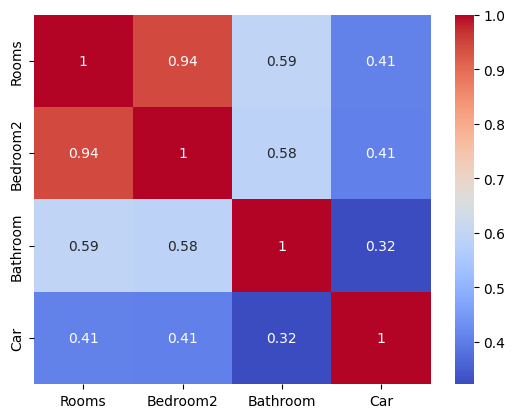

In [34]:
sns.heatmap(df[room_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

In [35]:
df["Rooms"].value_counts()

Rooms
3     5881
2     3648
4     2688
1      681
5      596
6       67
7       10
8        8
10       1
Name: count, dtype: int64

In [36]:
pd.set_option("display.float_format", "{:.4f}".format)
df[["Price","Rooms","Bedroom2","Bathroom","Car"]].corr()

,Price,Rooms,Bedroom2,Bathroom,Car
Price,1.0000,0.4966,0.4760,0.4670,0.2390
Rooms,0.4966,1.0000,0.9442,0.5929,0.4085
Bedroom2,0.4760,0.9442,1.0000,0.5847,0.4053
Bathroom,0.4670,0.5929,0.5847,1.0000,0.3222
Car,0.2390,0.4085,0.4053,0.3222,1.0000


# FINAL ANALYSIS OF THE NUMERICAL COLUMNS

## Analysis of Columns

**Target Column** - Price

**Numerical Columns**

*(int64 / float64)*

1. Rooms  
   : Number of rooms in the house. Range : **1 - 10**.  
   Null values : NA 
   Action: **Keep** (Strong predictor of price.)

3. Distance  
   : Distance of property from Melbourne CBD (in km). Range roughly : **0.7 - 50 km**.  
   Houses closer to city usually cost more.  
   Null values : NA  
   Action: **Keep**

4. Postcode  
   : Postal code of the suburb. Although numeric, it represents a **location identifier** (NOT MEASURABLE) 
   No Null values.  
   Action: **Drop or convert to categorical**

5. Bedroom2  
   : Number of bedrooms. Similar to `Rooms` highly correlated with it. Range roughly : **1 - 20**.  
   No null values. (95% of columns have same rooms == bedroom2).  
   Action: **Might drop it**

6. Bathroom  
   : Number of bathrooms in the property. Range roughly : **1 - 8**.  
   More bathrooms : higher value houses.  
   No null values.  
   Action: **Keep**

7. Car  
   : Number of parking spaces available. Range roughly : **0 - 10**.  
   Some missing values present.  
   Fix: **Fill null values with median and change column name**

8. Landsize  
   : Total land size of the property (square meters). Range : **0 to very large values**.  
   Some extreme values and possible outliers exist.  
   Null values present.  
   Fix: **Fill with median or remove extreme outliers**

9. BuildingArea  
   : Building size of the house (square meters).  
   Contains **many missing values** and wide range.  
   Fix: **Fill with median or consider dropping if missing percentage is too high**

10. YearBuilt  
   : Year the property was built. Expected realistic range : **1850 - 2020**.  
   Some unrealistic values exist.  
   Null values : present.  
   Fix:  
   - Remove unrealistic years (<1800)  
   - Fill missing values with **median**

11. Lattitude  
    : Geographic latitude coordinate of the property.  
    No null values.  
    Action: **Keep**

12. Longtitude  
    : Geographic longitude coordinate of the property.  
    No null values.  
    Action: **Keep**

13. Propertycount  
    : Number of properties in the suburb. Indicates population density of the area.  
    No null values.  
    Action: **Keep**

# Categorical Columns Analysis

In [38]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: Suburb
Suburb
Reservoir         359
Richmond          260
Bentleigh East    249
Preston           239
Brunswick         222
                 ... 
Attwood             1
Wallan              1
New Gisborne        1
Plumpton            1
Monbulk             1
Name: count, Length: 314, dtype: int64

Column: Address
Address
5 Charles St      3
13 Robinson St    3
5 Margaret St     3
28 Blair St       3
14 Arthur St      3
                 ..
12 Strada Cr      1
77 Merrett Dr     1
83 Power St       1
96 Verdon St      1
6 Agnes St        1
Name: count, Length: 13378, dtype: int64

Column: Type
Type
h    9449
u    3017
t    1114
Name: count, dtype: int64

Column: Method
Method
S     9022
SP    1703
PI    1564
VB    1199
SA      92
Name: count, dtype: int64

Column: SellerG
SellerG
Nelson           1565
Jellis           1316
hockingstuart    1167
Barry            1011
Ray               701
                 ... 
Area                1
SN                  1
PRD                 1
Rexhepi 

In [39]:
# checking for unique value in each columns:
for col in categorical_cols:
    print(col, ":", df[col].nunique())

Suburb : 314
Address : 13378
Type : 3
Method : 5
SellerG : 268
Date : 58
CouncilArea : 33
Regionname : 8


In [40]:
low_card_cols = ["Type","Method","Regionname"]
high_card_cols = ["Suburb","SellerG", "Address"]
med_card_cols = ["CouncilArea"]

In [41]:
category_dict = {}

for col in low_card_cols:
    category_dict[col] = df[col].unique().tolist()

category_dict

{'Type': ['h', 'u', 't'],
 'Method': ['S', 'SP', 'PI', 'VB', 'SA'],
 'Regionname': ['Northern Metropolitan',
  'Western Metropolitan',
  'Southern Metropolitan',
  'Eastern Metropolitan',
  'South-Eastern Metropolitan',
  'Eastern Victoria',
  'Northern Victoria',
  'Western Victoria']}

**Categorical Columns**

1. Suburb                              : High cardinality (300+ suburbs). One-hot encoding will create too many columns.  
                                        Better option: Frequency encoding or Target encoding.  
                                        Null values: None observed.

2. Address                             : Extremely high cardinality (almost every row unique).  
                                        No predictive structure for modeling.  
                                        Action: Drop column.

3. Type                                : 3 categories (h = house, u = unit/apartment, t = townhouse).  
                                        No hierarchical relationship.  
                                        Encoding: One-hot encoding.  
                                        Null values: None.

4. Method                              : ~5 categories (S, SP, PI, VB, SA representing sale method).  
                                        No natural hierarchy.  
                                        Encoding: One-hot encoding.  
                                        Null values: Few possible missing values → fill with "Unknown" if present.

5. SellerG                             : High cardinality (many real estate agents).  
                                        One-hot encoding would create too many features and may introduce noise.  
                                        Action: Drop column or use frequency encoding if agent influence is considered important.  
                                        Null values: None observed.

6. CouncilArea                         : Medium cardinality (30 regions).  
                                        One-hot encoding is possible but may increase dimensionality moderately.  
                                        Recommended: One-hot encoding or target encoding depending on model complexity.  
                                        Null values: Some missing values → fill with "Unknown".

7. Regionname                          : Low cardinality (8 regions).  
                                        No hierarchy between regions.  
                                        Encoding: One-hot encoding.  
                                        Null values: None observed.

8. Date                                : Date of property sale.  
                                        Not useful in raw string format.  
                                        Feature engineering required.  
                                        Convert into numerical features such as:  
                                            - Sale_Year  
                                            - Sale_Month  
                                            - Property_Age_at_Sale (optional)  
                                        Null values: None observed.

# Checking for outliers

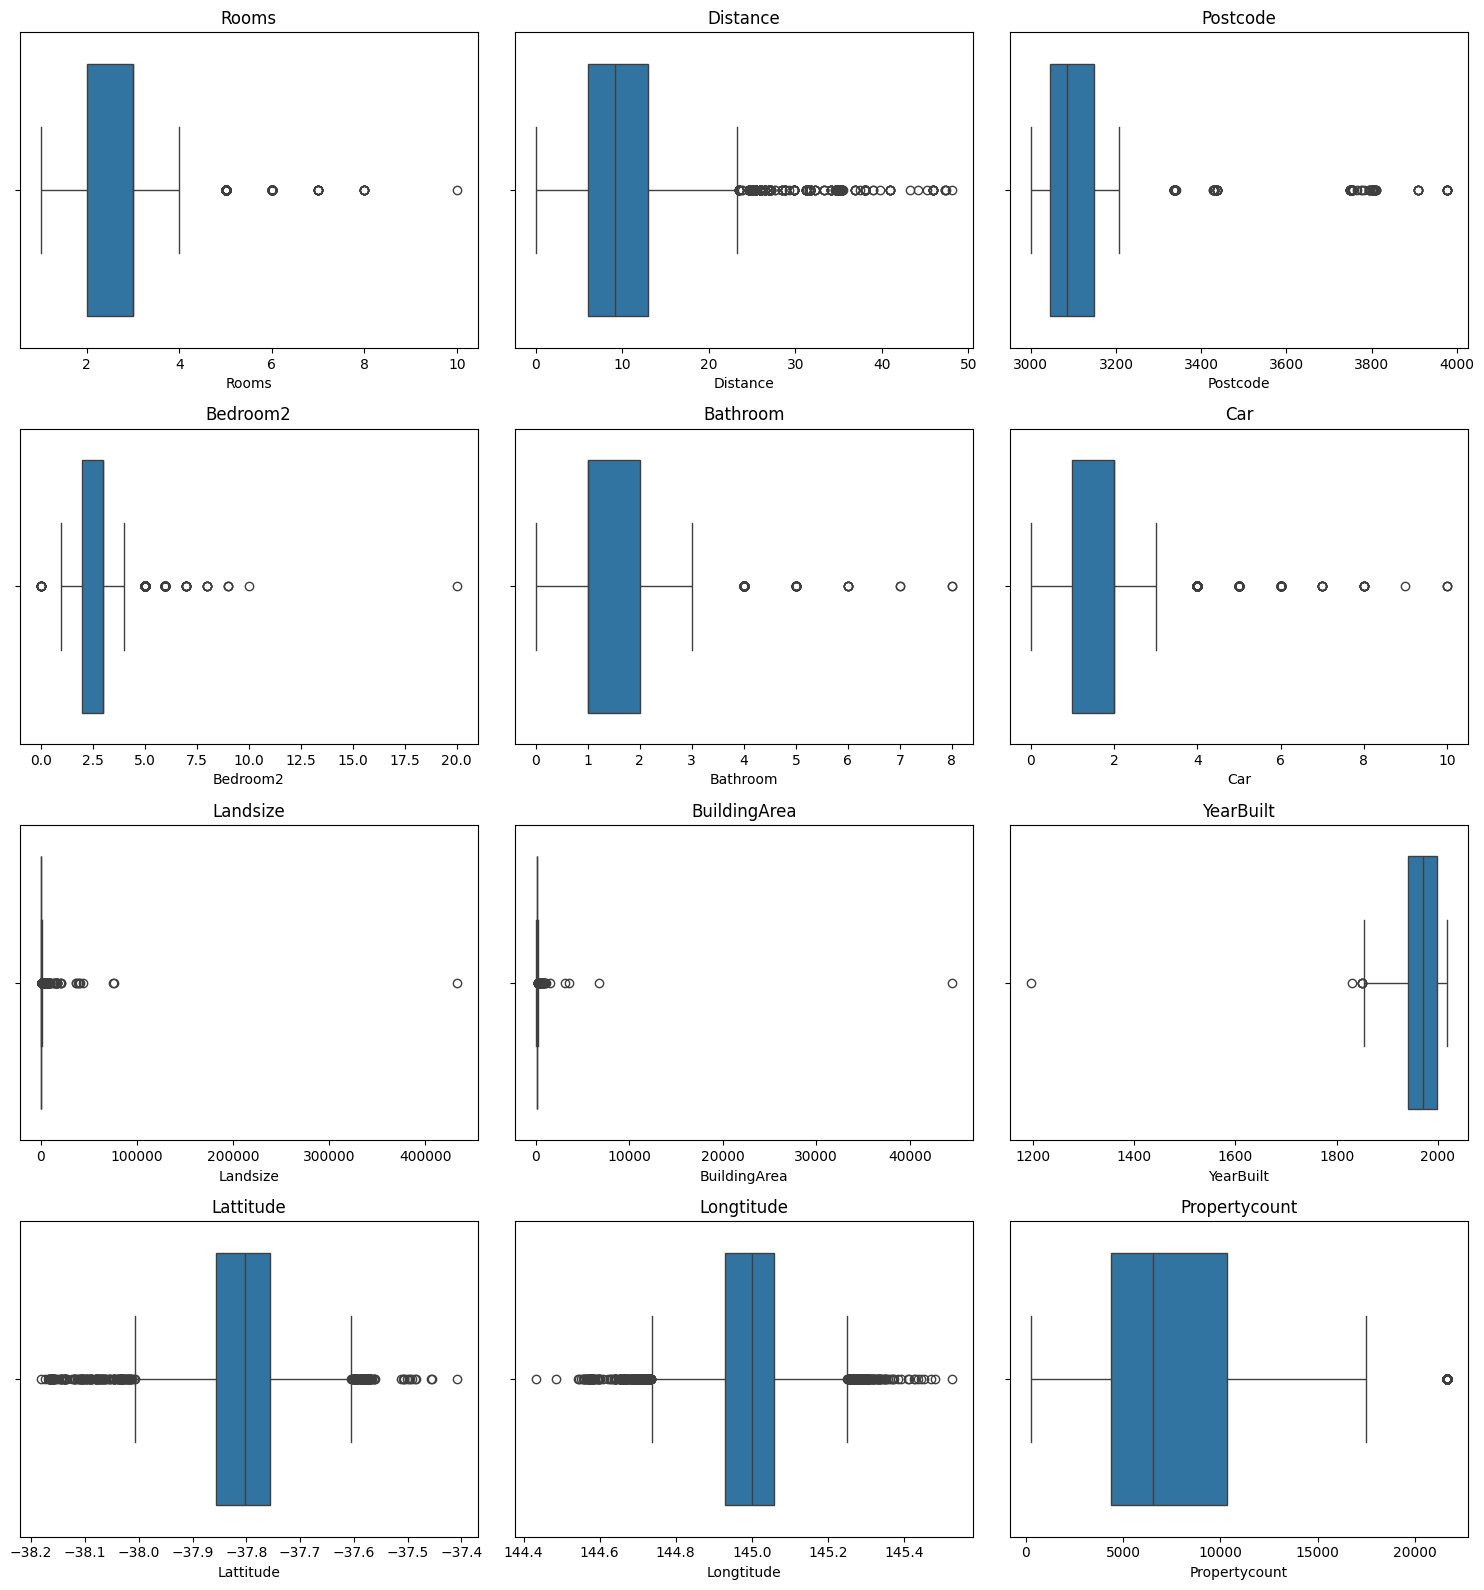

In [43]:
import math

# select numerical columns except target
numerical_cols = df.select_dtypes(include=["number"]).columns.drop("Price")

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()